In [ ]:
# Problem statement:

# using both images data and structured tabular data to predict a continuous target variable
# learning how to build a multimodal ML model by combining visual and numerical features
# using CNNs to extract meaningful features from images
# integrating image features with tabular data to improve model learning
# applying a neural network model for regression tasks
# evaluating model performance using MAE and RMSE

# using CIFAR-10 dataset for images along with a synthetic tabular dataset

In [1]:
!pip install tensorflow opencv-python

import pandas as pd
import numpy as np
import cv2
import os
import requests
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.layers import Input, Dense, Concatenate
from tensorflow.keras.models import Model

In [16]:
# loadding the CIFAR-10 dataset
from tensorflow.keras.datasets import cifar10

(X_images, y_labels), _ = cifar10.load_data()

X_images = X_images[:500]
y_labels = y_labels[:500]

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [17]:
# creating a synthetic tabular data since real housing image dataset is complex

df = pd.DataFrame({
    "bedrooms": np.random.randint(1, 5, size=len(X_images)),
    "bathrooms": np.random.randint(1, 3, size=len(X_images)),
    "area": np.random.randint(500, 3000, size=len(X_images)),
    "price": np.random.randint(100000, 500000, size=len(X_images))
})

df.head()

,bedrooms,bathrooms,area,price
0,1,1,2717,112739
1,2,2,1543,431801
2,3,1,1728,202296
3,1,1,795,331269
4,1,2,2657,258869


In [18]:
# resizing images to 224x224 and preprocessing
IMG_SIZE = 224

images_resized = np.array([
    cv2.resize(img, (IMG_SIZE, IMG_SIZE)) for img in X_images
])

images_resized = preprocess_input(images_resized)

print("Image shape:", images_resized.shape)

Image shape: (500, 224, 224, 3)


In [19]:
# loading pretrained ResNet abd extracting features
base_model = ResNet50(weights="imagenet", include_top=False, pooling="avg")

image_features = base_model.predict(images_resized)

print("Image feature shape:", image_features.shape)

16/16 ━━━━━━━━━━━━━━━━━━━━ 82s 5s/step
Image feature shape: (500, 2048)


In [20]:
# separating features and target and scale tabular data
X_tabular = df.drop("price", axis=1)
y = df["price"]

scaler = StandardScaler()
X_tabular = scaler.fit_transform(X_tabular)

In [21]:
#splitting into training and testing sets
X_tab_train, X_tab_test, img_train, img_test, y_train, y_test = train_test_split(
    X_tabular, image_features, y, test_size=0.2, random_state=42
)

In [22]:
# creating a cnn that processes tabular and image features and combines them

tabular_input = Input(shape=(X_tab_train.shape[1],))
x1 = Dense(64, activation='relu')(tabular_input)


image_input = Input(shape=(image_features.shape[1],))
x2 = Dense(128, activation='relu')(image_input)


combined = Concatenate()([x1, x2])


x = Dense(64, activation='relu')(combined)
output = Dense(1)(x)

model = Model(inputs=[tabular_input, image_input], outputs=output)

model.compile(optimizer='adam', loss='mse')

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_5       │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │        256 │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 128)       │    262,272 │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 192)       │          0 │ dense_4[0][0],    │
│ (Concatenate)       │                   │            │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 64)        │     12,352 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 1)         │         65 │ dense_6[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 274,945 (1.05 MB)

 Trainable params: 274,945 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
# training the multimodal model on combined tabular and image data
history = model.fit(
    [X_tab_train, img_train],
    y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=32
)

Epoch 1/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 96395362304.0000 - val_loss: 97788968960.0000
Epoch 2/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 95832276992.0000 - val_loss: 97110663168.0000
Epoch 3/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 95060148224.0000 - val_loss: 96201539584.0000
Epoch 4/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 94054825984.0000 - val_loss: 95016132608.0000
Epoch 5/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 92758622208.0000 - val_loss: 93523255296.0000
Epoch 6/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 91148877824.0000 - val_loss: 91690655744.0000
Epoch 7/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 89177841664.0000 - val_loss: 89493348352.0000
Epoch 8/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 86822133760.0000 - val_loss: 86919176192.0000
Epoch 9/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 84113956864.0000 - val_loss: 83924942848.0000
Epoch 10/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - l

In [26]:
# predictions using the trained model
y_pred = model.predict([X_tab_test, img_test])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


In [27]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 212493.875
RMSE: 242139.19382041396


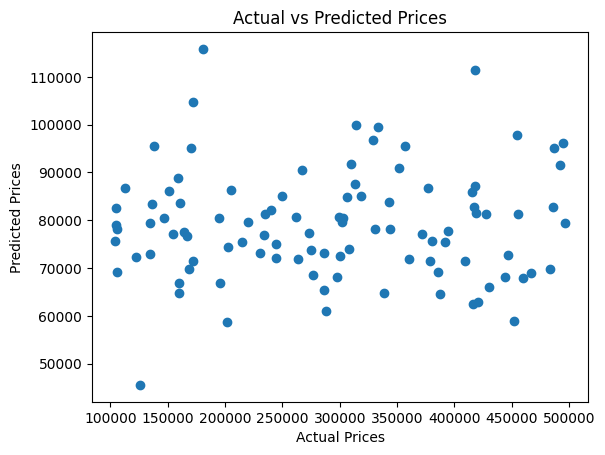

In [28]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.show()

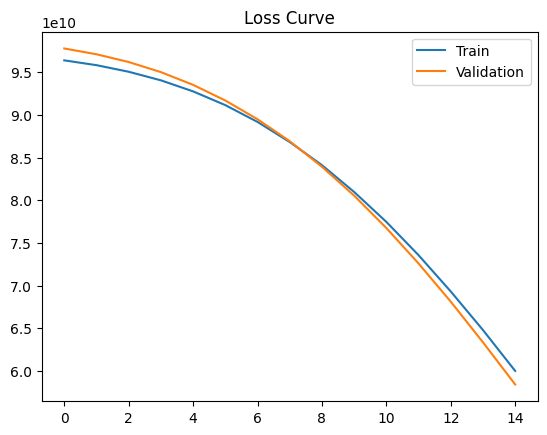

In [29]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['Train', 'Validation'])
plt.title("Loss Curve")
plt.show()

In [ ]:
# Results and final insights:

# the image dataset and syntehtic tabular data were combined into a multimodal dataset
# CNNs were used to extract meaningful features from images
# tabular features were integrated with image features to form a combined feature space
# the neural network model was able to process both image and tabular inputs side by side
# model performance was evaluated using MAE and RMSE metrics
# predictions are not perfectly accurate because the dataset is synthetic and does not represent real-world relationships
# the project successfully demonstrates how multimodal learning can be implemented using deep learning techniques